<span style="color:Red">

# Road Segmentation using Classical approach

</span>

In [68]:
'''
Fragment to try on : 
# 11545_sat
# 14361_sat
# 4227_sat
# 5279_sat
# 17193_sat

 Classical road segmentation on aerial map.

    Pipeline:
      1. CLAHE on L(lightness) channel (LAB) - normalize lighting , improve contrast 
      2. HSV threshold - roads: low saturation, mid brightness (gray-ish)
      3. Morphological close - fill gaps in road interiors
      4. Morphological open  - remove small noise blobs
      5. Contour filter - keep only large or elongated regions


      
CLAHE (Contrast Limited Adaptive Histogram Equalization)  - works by dividing img to smaller 
& adjust contrast in each part, helps in avoiding too bright or too dark
    parameters : Cliplimit ( threshold for contrast limiting : default - 40)
    titleGridSize : sets no of rows and columns ( deafaul t; 8 * 8)

LAB - Lightness [0-255], (Green -Red)[+ve : R, -ve: G] , (Blue-Yellow)[+ve : Y, -ve: B]
'''

'\nFragment to try on : \n# 11545_sat\n# 14361_sat\n# 4227_sat\n# 5279_sat\n# 17193_sat\n\n Classical road segmentation on aerial map.\n\n    Pipeline:\n      1. CLAHE on L(lightness) channel (LAB) - normalize lighting , improve contrast \n      2. HSV threshold - roads: low saturation, mid brightness (gray-ish)\n      3. Morphological close - fill gaps in road interiors\n      4. Morphological open  - remove small noise blobs\n      5. Contour filter - keep only large or elongated regions\n\n\n\nCLAHE (Contrast Limited Adaptive Histogram Equalization)  - works by dividing img to smaller \n& adjust contrast in each part, helps in avoiding too bright or too dark\n    parameters : Cliplimit ( threshold for contrast limiting : default - 40)\n    titleGridSize : sets no of rows and columns ( deafaul t; 8 * 8)\n\nLAB - Lightness [0-255], (Green -Red)[+ve : R, -ve: G] , (Blue-Yellow)[+ve : Y, -ve: B]\n'

In [50]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize, remove_small_objects
from scipy.ndimage import label as sp_label
#  scipy.ndimage.label is used to identify and label distinct, connected components (or clusters/objects) in a binary image or array.

In [42]:
img = cv2.imread("DeepGlobe_Dataset/train/11545_sat.jpg")
#img = cv2.imread("DeepGlobe_Dataset/train/17193_sat.jpg")

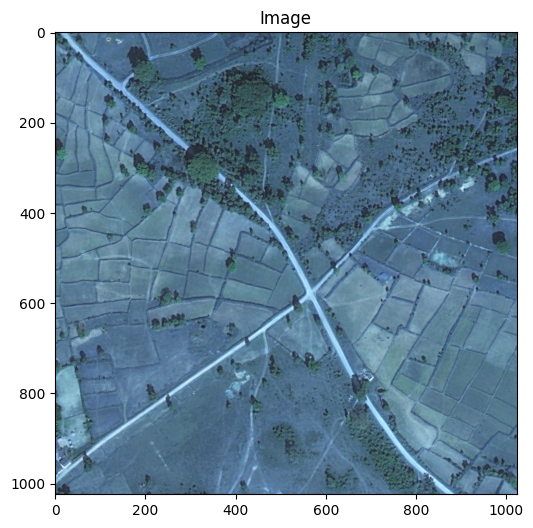

In [43]:
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Image")
plt.show()

In [69]:
# Possible approches 
# METHOD 1 — Adaptive Thresholding (Auto HSV)
# METHOD 2 — K-Means Clustering
# METHOD 3 — Histogram-Based Auto Threshold
# METHOD 4 - Watershed Algorithm
# METHOD 5 - MeanShift Filtering: Use cv2.pyrMeanShiftFiltering to smooth the image while preserving edges, which helps in grouping similar road pixels together.


#### Adaptive thresholding 
- algorithm determines the threshold for a pixel based on a small region around it. 
- different threshold for differnet regions of same image 

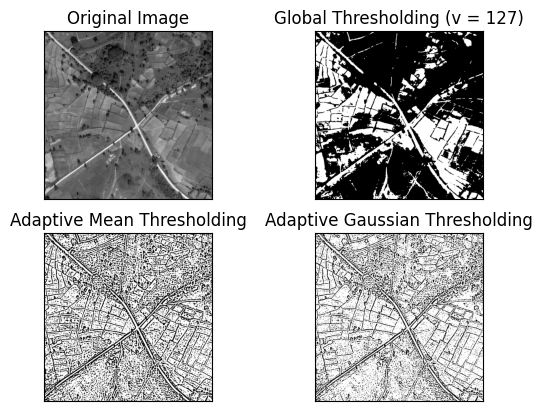

In [46]:

img = cv2.imread("DeepGlobe_Dataset/train/11545_sat.jpg", cv2.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img = cv2.medianBlur(img,5)

ret,th1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
th2 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_MEAN_C,\
            cv2.THRESH_BINARY,11,2)
th3 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,11,2)

titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]

for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

Histogram-Based Auto Threshold
----------------------------------------------------------------------
- Ostu's Method
- Triangle Method
- IsoData (Iterative Selection)
- Minimum
- Maximum Entropy (Kapur)
- Balanced Histogram Threshold (BHT)
- Yen Method

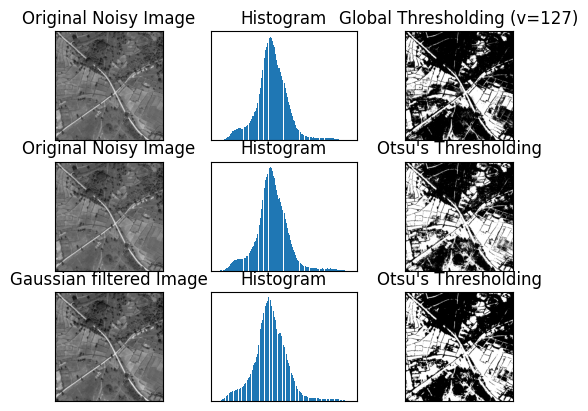

In [47]:
 
img = cv2.imread("DeepGlobe_Dataset/train/11545_sat.jpg", cv2.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
 
# global thresholding
ret1,th1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
 
# Otsu's thresholding
ret2,th2 = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
 
# Otsu's thresholding after Gaussian filtering
blur = cv2.GaussianBlur(img,(5,5),0)
ret3,th3 = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
 
# plot all the images and their histograms
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
          'Original Noisy Image','Histogram',"Otsu's Thresholding",
          'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]
 
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

generalise : no hsv - no assumption

- superpixels (SLIC) - break img into meaningful region
- color + texture scoring -> find road -like regions 
- Graph Connectivity -> keep only continois regions
- Morphology + smoothing - clean final mask 

## CLassical Approach of Road Segmentation - OpenCv

In [70]:
"""
GENERALISED ROAD SEGMENTATION PIPELINE
img types: satellite imagery, drone footage, Google Maps, stitched maps, custom datasets ...
 
Key features for generalisation:
  - Otsu-based ADAPTIVE thresholds  -> no fixed HSV values to tune
  - Cue confidence scoring          -> weak cues get lower weight automatically
  - Scale-normalised geometry       -> aspect/area filters adapt to image size
  - Multi-directional morphology    -> catches horizontal + vertical roads
  - Shadow + building suppression   -> reduces two biggest false-positive sources
 
Output: binary road mask, overlay, skeleton, eval (if GT available)
"""

'\nGENERALISED ROAD SEGMENTATION PIPELINE\nimg types: satellite imagery, drone footage, Google Maps, stitched maps, custom datasets ...\n\nKey features for generalisation:\n  - Otsu-based ADAPTIVE thresholds  -> no fixed HSV values to tune\n  - Cue confidence scoring          -> weak cues get lower weight automatically\n  - Scale-normalised geometry       -> aspect/area filters adapt to image size\n  - Multi-directional morphology    -> catches horizontal + vertical roads\n  - Shadow + building suppression   -> reduces two biggest false-positive sources\n\nOutput: binary road mask, overlay, skeleton, eval (if GT available)\n'

In [52]:
INPUT_PATH  = "DeepGlobe_Dataset/train/17193_sat.jpg"                   # top-down map
#OUTPUT_DIR  = "output/"
GT_PATH     =  "DeepGlobe_Dataset/train/17193_mask.png"                #Ground_truth mask
                                  
 
# Fixed thresholds / values
SCALE_WIDTH       = 1024       # resize to this width; None = no resize
CLAHE_CLIP        = 2.5        # CLAHE contrast limit
DENOISE_H         = 6          # fastNlMeansDenoisingColored h param
FUSION_THRESH     = 0.35      # road if weighted vote >= this (lower = more roads)
SHADOW_L_MAX      = 60         # LAB L below this = shadow pixel
SPUR_MIN_LEN      = 10         # skeleton spur pruning min length (px)
MIN_ROAD_AREA_FRAC= 0.0002  #0.00005    # min blob area as fraction of image area (scale-adaptive)
MIN_ASPECT        = 2.2        # min elongation ratio to keep a contour
MAX_SOLIDITY      = 0.87       # blobs more solid than this = buildings
 
#os.makedirs(OUTPUT_DIR, exist_ok=True)
print("setup ready.")

setup ready.


Loaded: 1024×1024 px


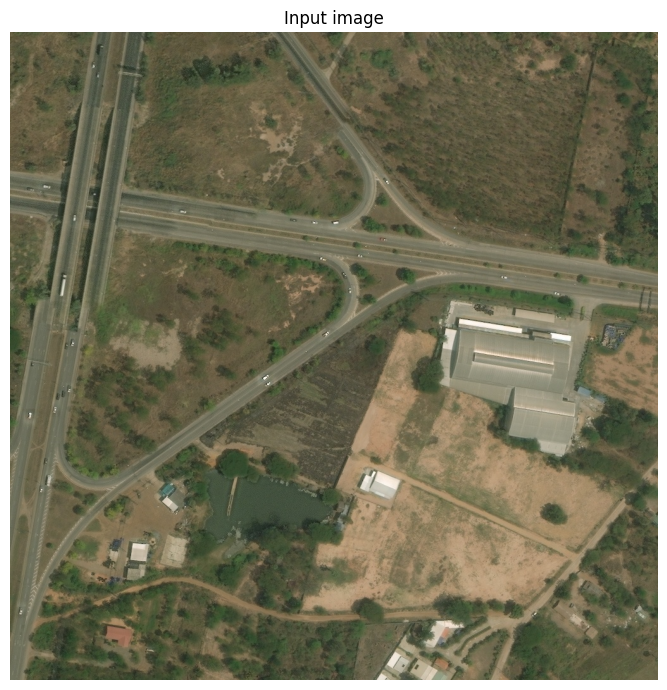

In [53]:
# Load image
def load_and_show(path):
    img = cv2.imread(path)
    assert img is not None, f"Cannot read: {path}"
    print(f"Loaded: {img.shape[1]}×{img.shape[0]} px")
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Input image"); plt.axis("off")
    plt.tight_layout(); plt.show()
    return img
 
raw = load_and_show(INPUT_PATH)

Preprocessing...
  Detected image type: satellite
  Preprocessed size: 1024×1024  type=satellite


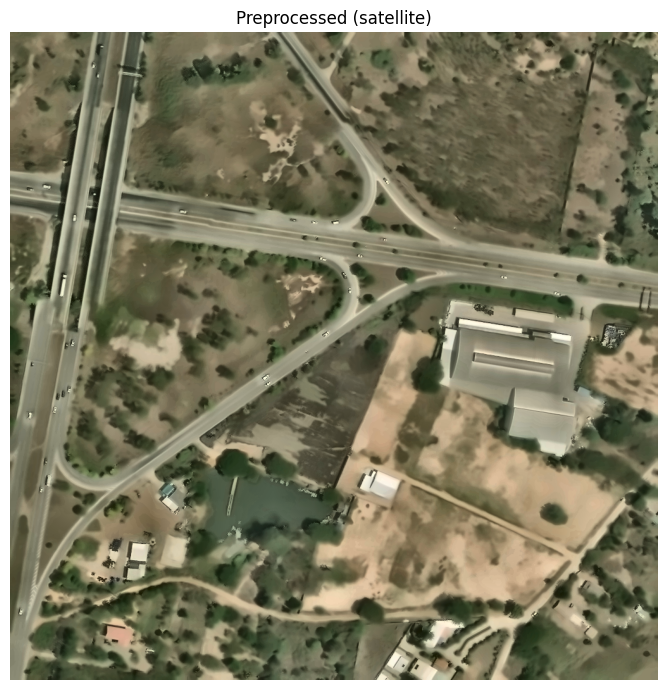

In [54]:
# Adaptive preprocessing
def detect_image_type(img):
    # classify image type: satellite, map_styled, drone
    # map_styled : high colour saturation variance + large uniform colour regions
    # drone      : very high resolution, less top-down angle (more perspective)
    # satellite  : default — moderate colour variance, top-down
   
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    sat_std = hsv[:,:,1].std()
 
    # Count large uniform colour blobs (map-styled images have many)
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, uni = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cnts, _= cv2.findContours(uni, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    large  = sum(1 for c in cnts if cv2.contourArea(c) > 0.01 * img.shape[0] * img.shape[1])
 
    if sat_std > 55 or large > 8:
        return 'map_styled'
    if img.shape[0] > 2000 or img.shape[1] > 2000:
        return 'drone'
    return 'satellite'
 
def preprocess(img, target_w=SCALE_WIDTH):
    """
    1. Resize to fixed width (maintains aspect ratio)
    2. Fast NL-means denoising - removes sensor noise without blurring edges
    3. CLAHE on L (LAB) - normalises lighting variation across image
    Returns (preprocessed_img, image_type_string).
    """
    # Resize
    if target_w and img.shape[1] != target_w:
        scale = target_w / img.shape[1]
        img   = cv2.resize(img, (target_w, int(img.shape[0]*scale)),
                           interpolation=cv2.INTER_AREA)
 
    img_type = detect_image_type(img)
    print(f"  Detected image type: {img_type}")
 
    # Denoise (skip for map_type- no sensor noise)
    if img_type != 'map_styled':
        img = cv2.fastNlMeansDenoisingColored(img, None,
                                               DENOISE_H, DENOISE_H, 7, 21)
 
    # CLAHE on L channel
    lab     = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=(16,16))
    l_eq    = clahe.apply(l)
    img     = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)
 
    return img, img_type
 
print("Preprocessing...")
img, img_type = preprocess(raw)
H, W = img.shape[:2]
print(f"  Preprocessed size: {W}×{H}  type={img_type}")
 
plt.figure(figsize=(12,7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Preprocessed ({img_type})"); plt.axis("off")
plt.tight_layout(); plt.show()
 

Computing color cue...
  Color cue coverage: 10.4%


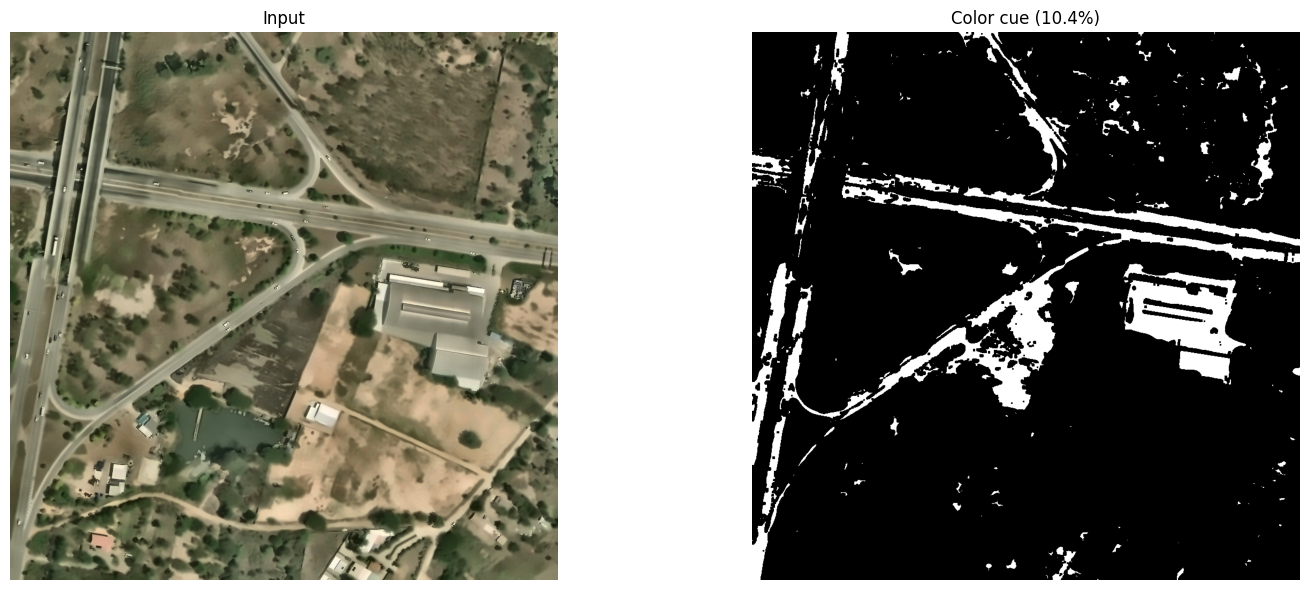

In [55]:
# Adaptive color hue
def adaptive_color_cue(img, img_type):
    """
    ADAPTIVE thresholding 
    For satellite / drone:
      - Compute Otsu threshold on LAB A and B channels to find neutral grey range
      - Roads occupy the low-chroma region: A and B both near 128
      - Reject very dark (shadow) and very bright (water glare, rooftops) via L
 
    For map_styled (Google Maps etc.):
      - Roads are explicitly drawn with a specific grey/beige tone
      - Use K-means (k=8) to find dominant colours, identify road colour cluster
        as the cluster with low saturation and mid-lightness, then threshold
        pixels within Euclidean distance of that cluster centre
 
    Returns float mask [0,1].
    """
    lab     = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
    l, a, b = lab[:,:,0], lab[:,:,1], lab[:,:,2]
    hsv     = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    sat     = hsv[:,:,1]
    val     = hsv[:,:,2]
 
    if img_type == 'map_styled':
        #K-means colour clustering to find road colour 
        pixels = img.reshape(-1, 3).astype(np.float32)
        k      = 10
        crit   = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
        _, labels, centres = cv2.kmeans(pixels, k, None, crit,
                                        5, cv2.KMEANS_PP_CENTERS)
        # Road cluster: low saturation, mid brightness, not green/blue
        best_c   = None
        best_score = 1e9
        for c in centres:
            bgr_c = c.astype(np.uint8).reshape(1,1,3)
            h_c   = cv2.cvtColor(bgr_c, cv2.COLOR_BGR2HSV)[0,0]
            s_c, v_c = float(h_c[1]), float(h_c[2])
            # Score: want low saturation + mid brightness
            score = s_c + abs(v_c - 140)
            if score < best_score and s_c < 60 and 80 < v_c < 220:
                best_score = score
                best_c     = c
 
        if best_c is not None:
            diff  = np.linalg.norm(pixels - best_c, axis=1).reshape(H, W)
            # Threshold at Otsu on the distance map
            dist_u8 = np.clip(diff, 0, 255).astype(np.uint8)
            ot, _   = cv2.threshold(dist_u8, 0, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            mask = (diff < ot * 0.6).astype(np.float32)
        else:
            # Fallback to standard path
            mask = (sat < 50).astype(np.float32)
 
    else:
        # Satellite / drone: Otsu-adaptive on LAB channels
        # A and B channels: compute neutral range dynamically
        # Roads cluster around (A=128, B=128) — use Otsu on |A-128| and |B-128|
 
        a_dev = np.abs(a - 128).astype(np.uint8)
        b_dev = np.abs(b - 128).astype(np.uint8)
 
        ot_a, _ = cv2.threshold(a_dev, 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        ot_b, _ = cv2.threshold(b_dev, 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)
 
        a_mask = (a_dev < ot_a * 1.0).astype(np.float32)
        b_mask = (b_dev < ot_b * 1.0).astype(np.float32)
 
        # L range: not too dark (shadow), not too bright (snow/glare)
        l_low  = np.percentile(l, 5)   # adaptive lower bound
        l_high = np.percentile(l, 97)   # adaptive upper bound
        l_mask = ((l > l_low) & (l < l_high)).astype(np.float32)
 
        # Saturation: roads are desaturated
        sat_thresh = np.percentile(sat, 60)  # lower 70% of pixels by saturation
        sat_mask   = (sat < sat_thresh).astype(np.float32)
 
        mask = a_mask * b_mask * l_mask * sat_mask
 
    # Smooth slightly
    mask = cv2.GaussianBlur(mask, (5,5), 1.5)
    mask = (mask > 0.96).astype(np.float32)
    return mask
 
print("Computing color cue...")
cue_color = adaptive_color_cue(img, img_type)
color_cov = cue_color.mean() * 100
print(f"  Color cue coverage: {color_cov:.1f}%")
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Input"); axes[0].axis("off")
axes[1].imshow(cue_color, cmap='gray', vmin=0, vmax=1); axes[1].set_title(f"Color cue ({color_cov:.1f}%)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

# drawback - assumes road to be color consistent


Computing texture cue (LBP)...
  Texture cue coverage: 14.0%


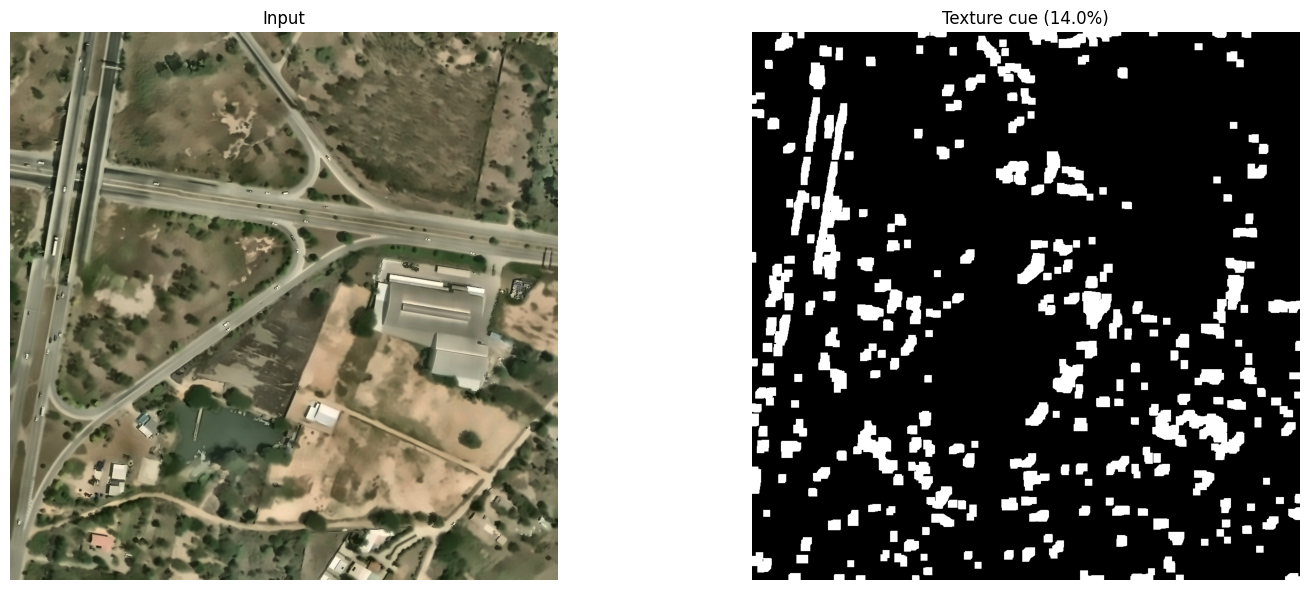

In [56]:
# Texture hue
def compute_lbp_variance(gray, radius=2, n_points=8, window=9):
    """
    Efficient LBP variance map using cv2.warpAffine shifts.
    Roads = smooth = low LBP code variance in local window.
    Returns float map in [0,1] where high = smooth.
    """
    gray  = gray.astype(np.float32)
    lbp   = np.zeros_like(gray)
 
    for i in range(n_points):
        angle = 2 * np.pi * i / n_points
        dx    = radius * np.cos(angle)
        dy    = -radius * np.sin(angle)
        M     = np.float32([[1, 0, dx], [0, 1, dy]])
        nb    = cv2.warpAffine(gray, M, (gray.shape[1], gray.shape[0]),
                               flags=cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_REPLICATE)
        lbp  += (nb >= gray).astype(np.float32) * (1 << i)
 
    lbp_f   = lbp
    mean_l  = cv2.boxFilter(lbp_f,   -1, (window, window))
    mean_l2 = cv2.boxFilter(lbp_f**2,-1, (window, window))
    var     = np.maximum(mean_l2 - mean_l**2, 0)
 
    # Normalise and invert: low variance → high road probability
    var_n   = var / (np.percentile(var, 99) + 1e-6)
    smooth  = 1.0 - np.clip(var_n, 0, 1)
    return smooth
 
def texture_cue(img):
    """
    LBP-based smoothness map.
    Adaptive threshold: Otsu on the variance map.
    Returns float mask [0,1].
    """
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    smooth  = compute_lbp_variance(gray)
 
    smooth_u8 = (smooth * 255).astype(np.uint8)
    ot, _     = cv2.threshold(smooth_u8, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask      = (smooth_u8 > ot ).astype(np.float32)
 
    # Clean noise
    k    = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=2)
    return mask
 
print("Computing texture cue (LBP)...")
cue_tex = texture_cue(img)
tex_cov = cue_tex.mean() * 100
print(f"  Texture cue coverage: {tex_cov:.1f}%")
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Input"); axes[0].axis("off")
axes[1].imshow(cue_tex, cmap='gray', vmin=0, vmax=1); axes[1].set_title(f"Texture cue ({tex_cov:.1f}%)"); axes[1].axis("off")
plt.tight_layout(); plt.show()
 

Computing edge density cue...
  Edge density cue coverage: 18.4%


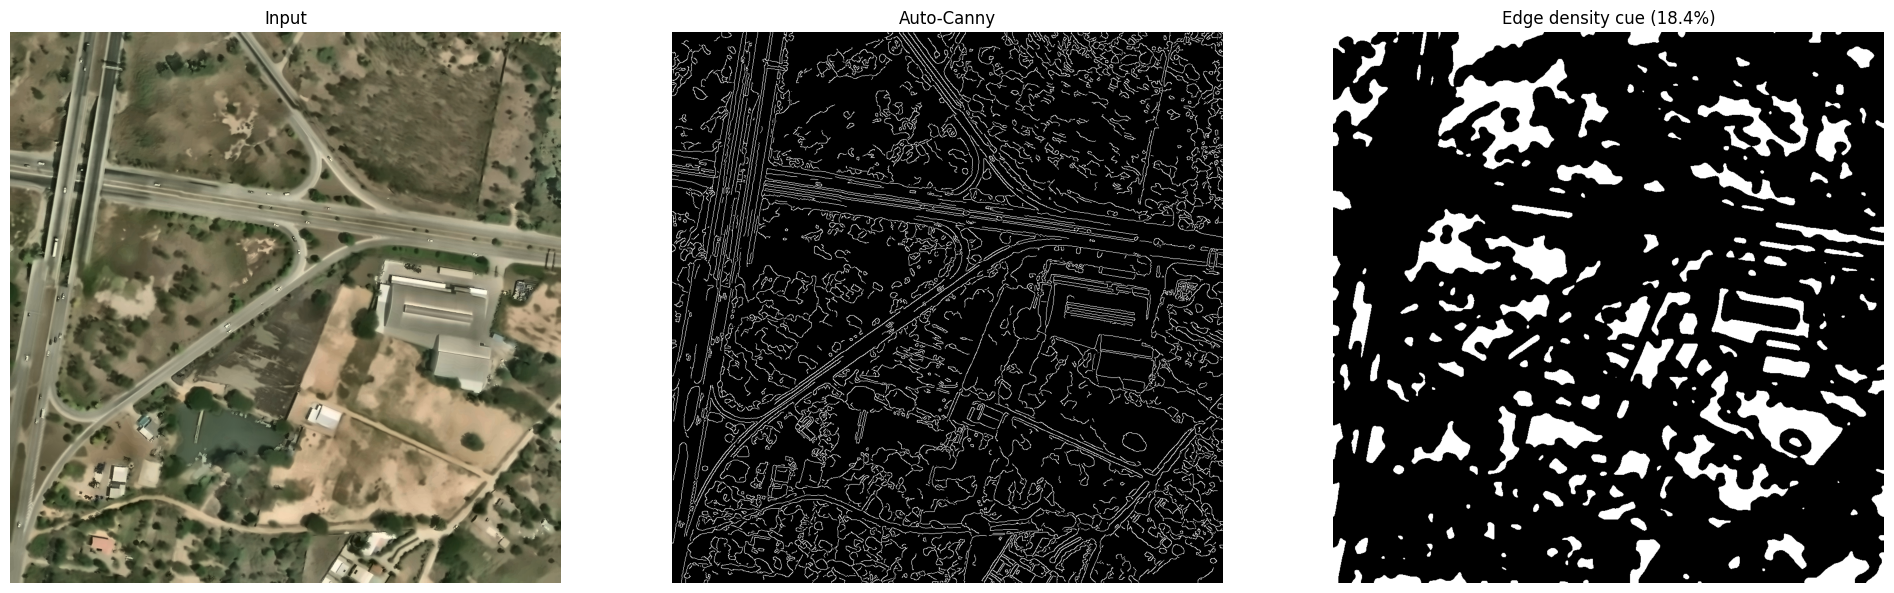

In [57]:
# Edge density cue
def edge_density_cue(img):
    """
    Road interiors have LOW edge density.
    Buildings and vegetation have HIGH edge density.
 
    Auto-Canny: thresholds set by Otsu on gradient magnitude.
    Density estimated by dilating edges + Gaussian smoothing.
    Adaptive threshold: Otsu on the density map.
 
    Returns float mask [0,1].
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 1.0)
 
    # Otsu threshold on gradient magnitude for Canny
    grad_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    mag    = np.sqrt(grad_x**2 + grad_y**2).astype(np.uint8)
    ot, _  = cv2.threshold(mag, 0, 255,
                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    edges  = cv2.Canny(blur, ot * 0.4, ot)
 
    # Density: dilate and smooth
    r  = max(5, W // 120)      # radius scales with image width
    k  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
    d  = cv2.dilate(edges, k).astype(np.float32) / 255.0
    d  = cv2.GaussianBlur(d, (2*r+1, 2*r+1), 0)
    d  = d / (d.max() + 1e-6)
 
    # Invert + threshold (Otsu)
    inv    = (1.0 - d)
    inv_u8 = (inv * 255).astype(np.uint8)
    ot2, _ = cv2.threshold(inv_u8, 0, 255,
                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask   = (inv_u8 > ot2).astype(np.float32)
    return mask, edges
 
print("Computing edge density cue...")
cue_edge, edges_vis = edge_density_cue(img)
edge_cov = cue_edge.mean() * 100
print(f"  Edge density cue coverage: {edge_cov:.1f}%")
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB));        axes[0].set_title("Input");          axes[0].axis("off")
axes[1].imshow(edges_vis, cmap='gray');                       axes[1].set_title("Auto-Canny");     axes[1].axis("off")
axes[2].imshow(cue_edge, cmap='gray', vmin=0, vmax=1);        axes[2].set_title(f"Edge density cue ({edge_cov:.1f}%)"); axes[2].axis("off")
plt.tight_layout(); plt.show()
 


Computing cue confidences...
  Cue 'color': coverage=10.4%  var=0.093  confidence=0.85
  Cue 'texture': coverage=14.0%  var=0.120  confidence=0.92
  Cue 'edge': coverage=18.4%  var=0.150  confidence=1.00
  Final weights: color=0.50  texture=0.20  edge=0.30


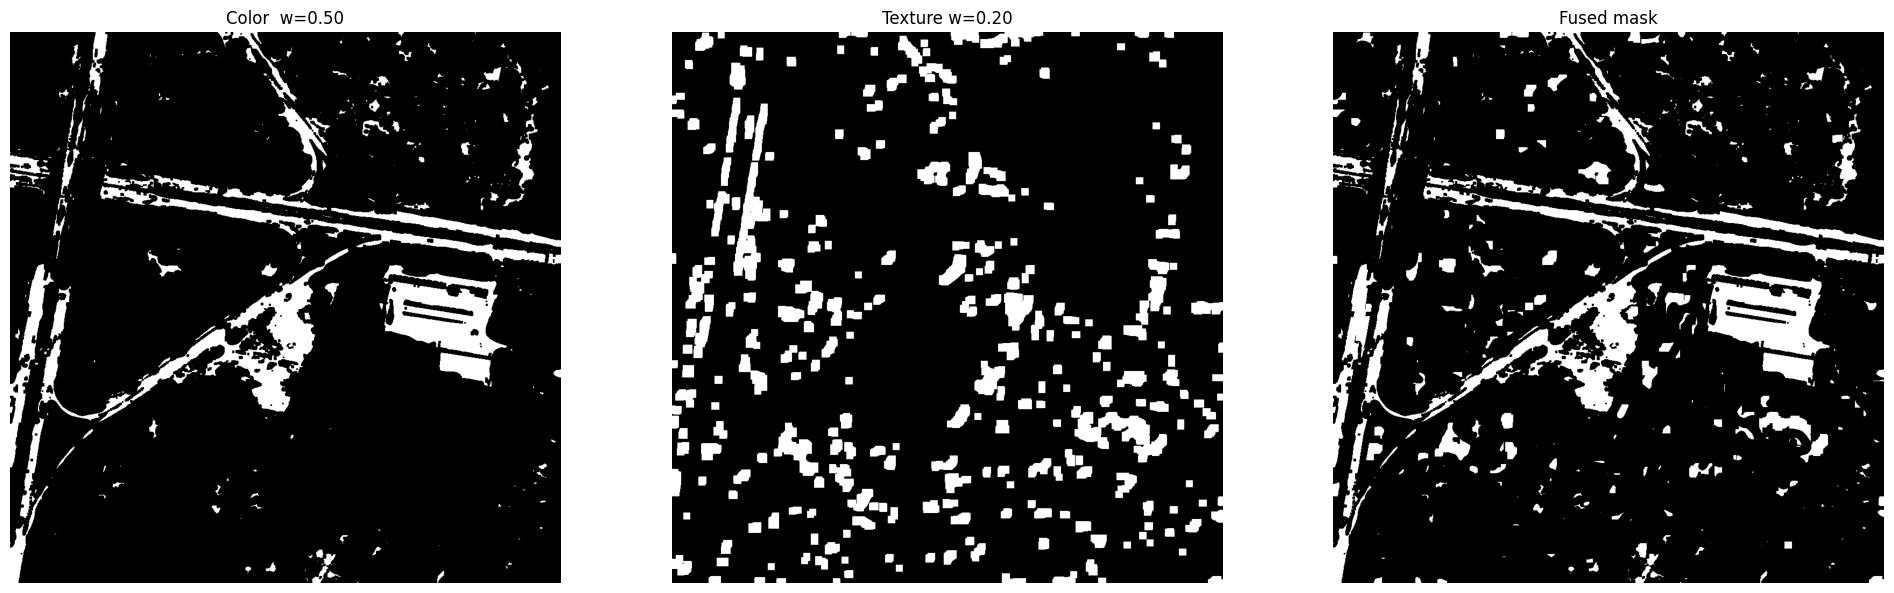

In [58]:
# confidence - weighted adaptive fusion 
def compute_cue_confidence(cue, name):
    """
    Score how informative a cue is for THIS image.
    A good cue has moderate coverage (neither all-white nor all-black)
    and reasonable spatial variance.
 
    Returns confidence in [0, 1].
    """
    coverage = cue.mean()
 
    # Ideal coverage: 5%-40% of image 
    # Penalise cues that are too sparse (<3%) or too broad (>55%)
    if coverage < 0.03 or coverage > 0.55:
        coverage_score = 0.2
    elif 0.05 <= coverage <= 0.35:
        coverage_score = 1.0
    else:
        # Linear falloff outside ideal zone
        if coverage < 0.05:
            coverage_score = coverage / 0.05 * 0.8 + 0.2
        else:
            coverage_score = max(0.2, 1.0 - (coverage - 0.35) / 0.2 * 0.8)
 
    # Spatial variance: good cue has structured patterns, not noise
    spatial_var = float(cue.var())
    var_score   = min(1.0, spatial_var / 0.15)
 
    conf = 0.6 * coverage_score + 0.4 * var_score
    print(f"  Cue '{name}': coverage={coverage*100:.1f}%  "
          f"var={spatial_var:.3f}  confidence={conf:.2f}")
    return conf
 
def adaptive_fuse(cue_c, cue_t, cue_e, threshold=FUSION_THRESH):
    """
    Fuse three cues with automatically computed weights.
    Weights derived from per-cue confidence scores:
      w_i = conf_i / sum(conf_all)
    A cue that produces a bad coverage estimate gets down-weighted.
    Floor weight = 0.1 so no cue is ignored completely.
    """
    print("Computing cue confidences...")
    conf_c = compute_cue_confidence(cue_c, "color")
    conf_t = compute_cue_confidence(cue_t, "texture")
    conf_e = compute_cue_confidence(cue_e, "edge")
 
    total  = conf_c + conf_t + conf_e + 1e-9
    wc, wt, we = conf_c/total, conf_t/total, conf_e/total
    wc = 0.5
    wt = 0.2
    we = 0.3

    # Apply floor weights so no cue is completely ignored
    #floor  = 0.85
    #wc     = max(wc, floor); wt = max(wt, floor); we = max(we, floor)
    total2 = wc + wt + we
    wc    /= total2; wt /= total2; we /= total2
 
    print(f"  Final weights: color={wc:.2f}  texture={wt:.2f}  edge={we:.2f}")
 
    fused  = wc * cue_c + wt * cue_t + we * cue_e
    mask   = (fused >= threshold).astype(np.uint8) * 255
    return mask, fused, (wc, wt, we)
 
raw_mask, score_map, weights = adaptive_fuse(cue_color, cue_tex, cue_edge)
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(cue_color, cmap='gray', vmin=0, vmax=1);   axes[0].set_title(f"Color  w={weights[0]:.2f}");   axes[0].axis("off")
axes[1].imshow(cue_tex,   cmap='gray', vmin=0, vmax=1);   axes[1].set_title(f"Texture w={weights[1]:.2f}"); axes[1].axis("off")
axes[2].imshow(raw_mask,  cmap='gray');                    axes[2].set_title("Fused mask");                  axes[2].axis("off")
plt.tight_layout(); plt.show()
 


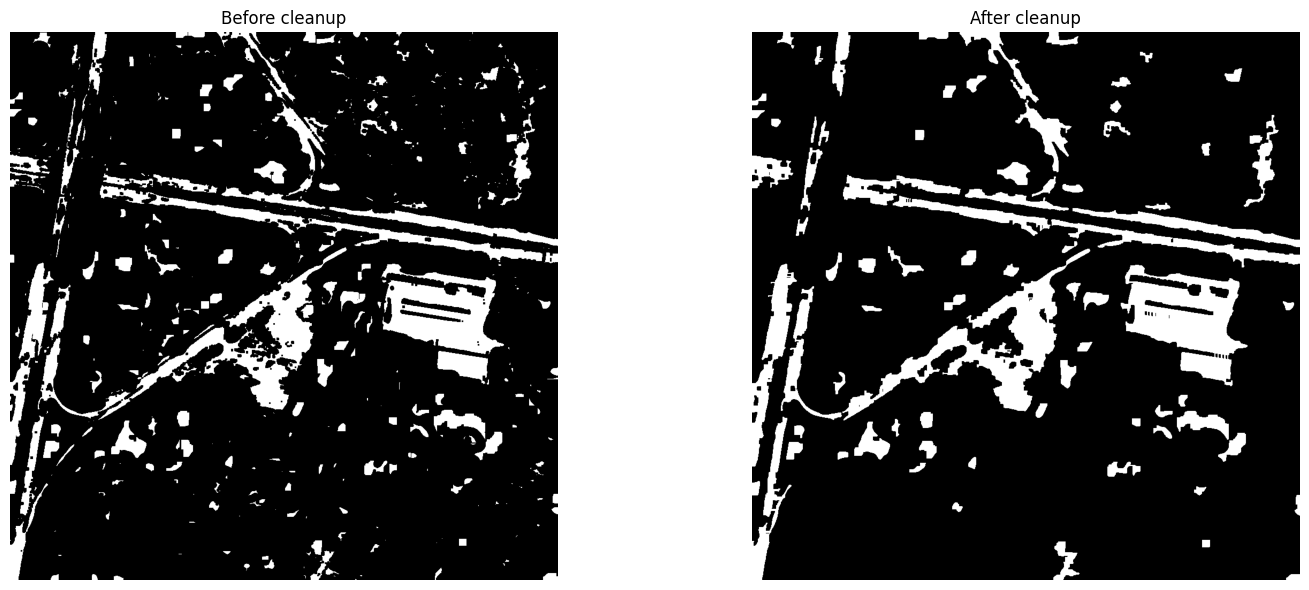

In [59]:
# Morphological cleanup
def morph_cleanup(mask):
    """
    Directional closing: apply horizontal + vertical structuring elements
    separately, then OR together. This reconnects broken road segments
    regardless of road orientation.
 
    Scale-adaptive kernel sizes based on image dimensions.
    """
    # Kernel sizes scale with image size
    base = max(3, W // 400)
 
    k_sq   = cv2.getStructuringElement(cv2.MORPH_RECT, (base*2-1, base*2-1))
    k_open = cv2.getStructuringElement(cv2.MORPH_RECT, (base-1, base-1))
    k_h    = cv2.getStructuringElement(cv2.MORPH_RECT, (base*3-1, 1))  # horizontal
    k_v    = cv2.getStructuringElement(cv2.MORPH_RECT, (1, base*3-1))  # vertical
    k_d1   = cv2.getStructuringElement(cv2.MORPH_RECT, (base*2-1, 1))  # diagonal approx
    k_d2   = cv2.getStructuringElement(cv2.MORPH_RECT, (1, base*2-1))
 
    m = mask.copy()
 
    # Pass 1: square close — fills internal gaps
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k_sq, iterations=1)
 
    # Pass 2: open — remove isolated noise
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k_open, iterations=1)
 
    # Pass 3: directional closes — reconnect near-parallel segments
    m_h  = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k_h, iterations=1)
    m_v  = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k_v, iterations=1)
    #m_d1 = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k_d1, iterations=1)
    #m_d2 = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k_d2, iterations=1)
    m    = cv2.bitwise_or(m, cv2.bitwise_or(m_h, m_v))
    #m    = cv2.bitwise_or(m, cv2.bitwise_or(m_h, cv2.bitwise_or(m_v, cv2.bitwise_or(m_d1, m_d2))))
 
    # Pass 4: final open to clean edges from directional pass
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k_open, iterations=1)
 
    # Remove tiny isolated components using connected components
    n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    min_area = int(MIN_ROAD_AREA_FRAC * H * W)
    clean    = np.zeros_like(m)
    for lbl in range(1, n_lab):
        if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == lbl] = 255
 
    return clean
 
clean_mask = morph_cleanup(raw_mask)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(raw_mask,   cmap='gray'); axes[0].set_title("Before cleanup"); axes[0].axis("off")
axes[1].imshow(clean_mask, cmap='gray'); axes[1].set_title("After cleanup");  axes[1].axis("off")
plt.tight_layout(); plt.show()
 
 

  Geometric filter: kept=31  dropped=87


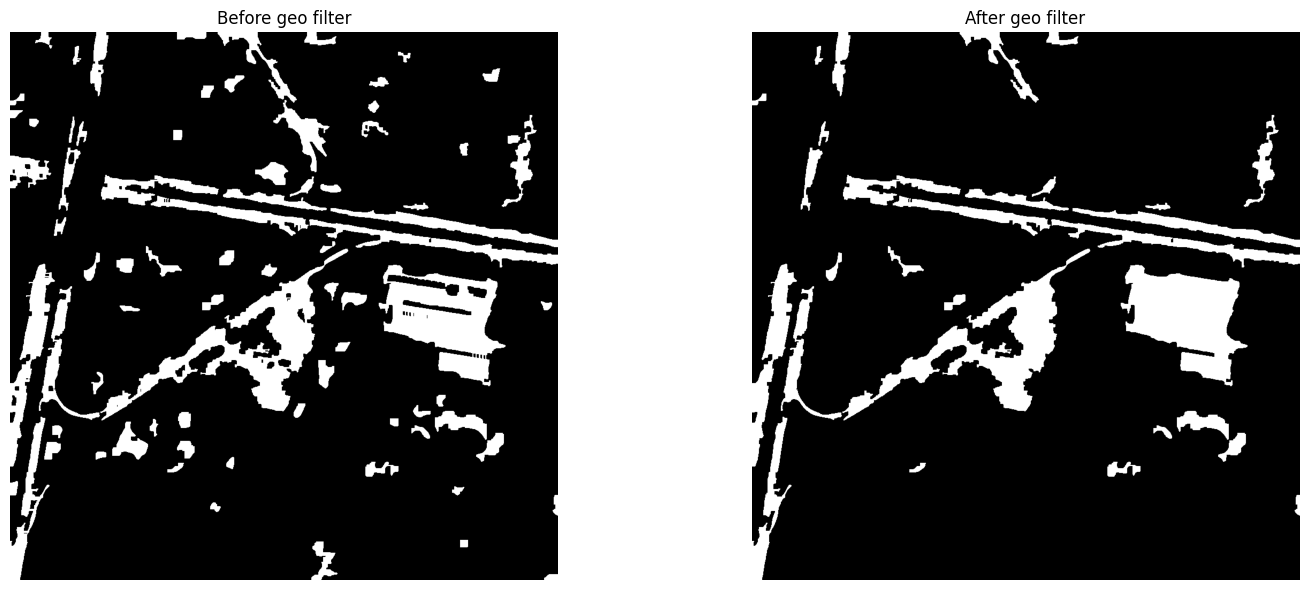

In [60]:
# Scale-adaptive geometric filtering
def geometric_filter(mask, img_area):
    """
    Filters contours by shape — roads are elongated, buildings are compact.
 
    All thresholds are SCALE-ADAPTIVE:
      min_area    scales with image pixel count
      aspect      fixed (shape is resolution-independent)
      solidity    fixed (shape is resolution-independent)
 
    Large area override: very large blobs (>0.5% of image) are kept
    regardless of aspect — these are main road surfaces.
    """
    min_area  = max(200, int(MIN_ROAD_AREA_FRAC * img_area))
    large_area= int(0.005 * img_area)   # unconditional keep threshold
 
    contours, _ = cv2.findContours(mask, cv2.RETR_CCOMP,
                                   cv2.CHAIN_APPROX_SIMPLE)
    filtered = np.zeros_like(mask)
    kept = dropped = 0
 
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            dropped += 1
            continue
 
        # Minimum bounding rectangle for aspect ratio
        rect      = cv2.minAreaRect(cnt)
        bw, bh    = rect[1]
        if bw < 1 or bh < 1:
            dropped += 1; continue
        aspect    = max(bw, bh) / min(bw, bh)
 
        # Solidity
        hull      = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity  = area / (hull_area + 1e-5)
 
        is_elongated = aspect   > MIN_ASPECT
        is_large     = area     > large_area
        is_compact   = solidity > MAX_SOLIDITY
 
        if (is_elongated or is_large) and not is_compact:
            cv2.drawContours(filtered, [cnt], -1, 255, -1)
            kept += 1
        else:
            dropped += 1
 
    print(f"  Geometric filter: kept={kept}  dropped={dropped}")
    return filtered
 
geo_mask = geometric_filter(clean_mask, H * W)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(clean_mask, cmap='gray'); axes[0].set_title("Before geo filter"); axes[0].axis("off")
axes[1].imshow(geo_mask,   cmap='gray'); axes[1].set_title("After geo filter");  axes[1].axis("off")
plt.tight_layout(); plt.show()
 

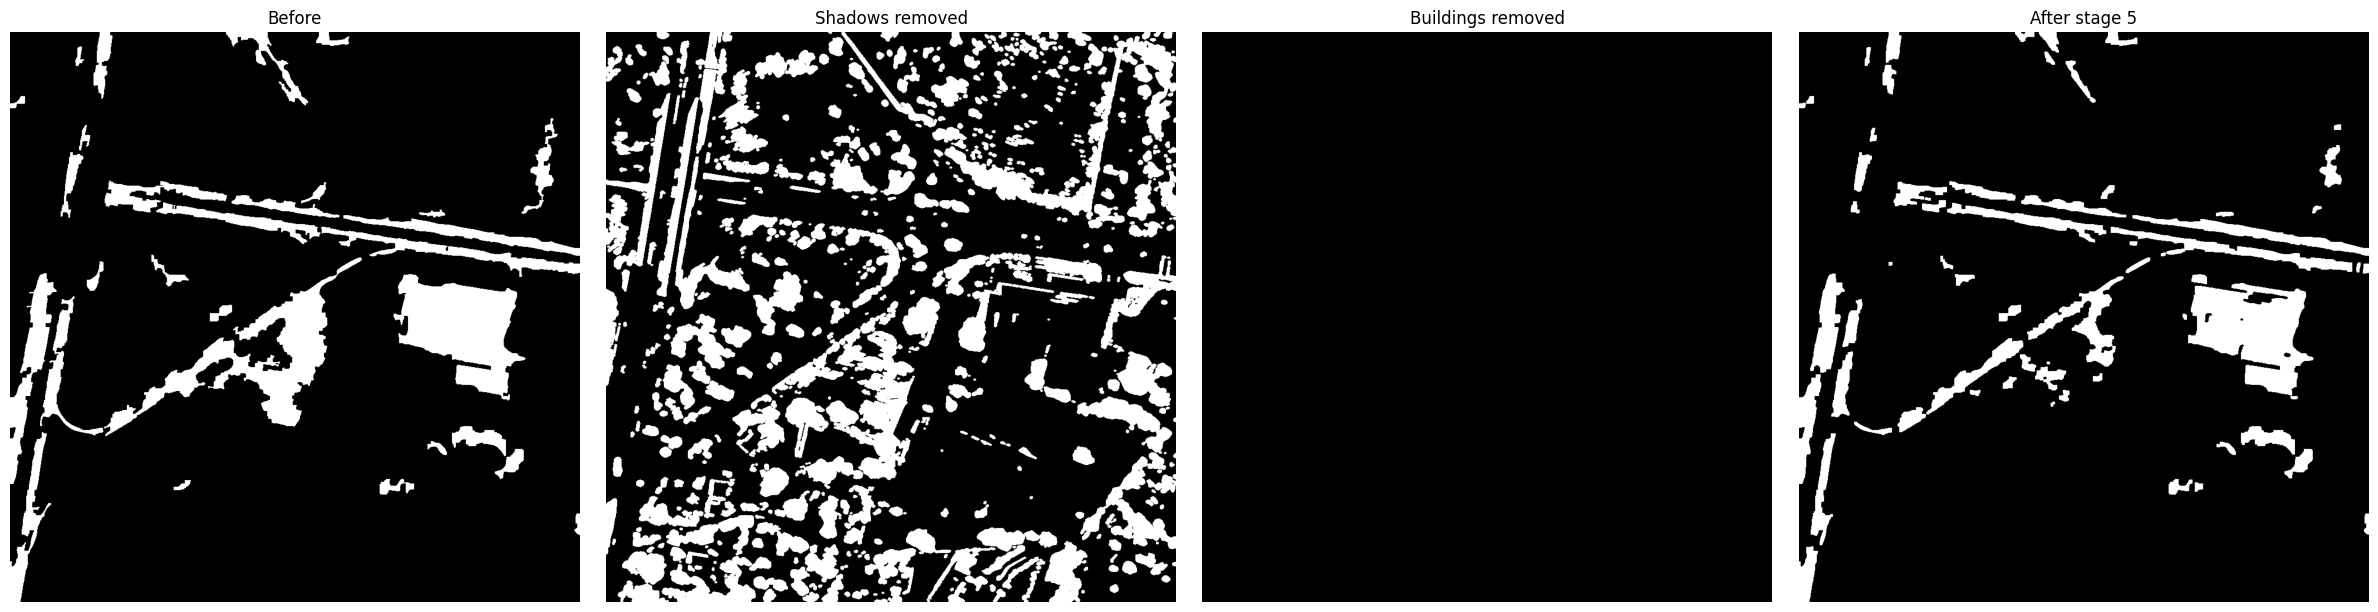

In [61]:
#Shadow + building removal
def remove_false_positives(mask, img):
    """
    Two passes:
 
    1. Shadow removal:
       Building shadows fall on roads and mimic road colour.
       Detect very dark pixels (low L in LAB) + high gradient
       at shadow boundary, subtract from mask.
 
    2. Building footprint removal:
       Rooftops can match road colour. Buildings are:
       - compact (solidity > 0.90)
       - near-square (aspect < 1.8)
       Subtract these from the mask.
    """
    lab     = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, _, _ = cv2.split(lab)
 
    # ── Shadow mask ──────────────────────────────────────
    # Adaptive shadow threshold: use SHADOW_L_MAX or 25th percentile, whichever is higher
    shadow_thresh = max(SHADOW_L_MAX, int(np.percentile(l, 20)))
    shadow        = (l < shadow_thresh).astype(np.uint8) * 255
 
    # Dilate shadow edges slightly to remove bleed
    ks = max(5, W//200)
    k  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks,ks))
    shadow = cv2.dilate(shadow, k, iterations=1)
    mask   = cv2.bitwise_and(mask, cv2.bitwise_not(shadow))
 
    # ── Building footprint removal ──────────────────────
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    bld_mask = np.zeros_like(mask)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 500: continue
        hull      = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity  = area / (hull_area + 1e-5)
        rect      = cv2.minAreaRect(cnt)
        bw, bh    = rect[1]
        if bw < 1 or bh < 1: continue
        aspect    = max(bw, bh) / min(bw, bh)
 
        if solidity > 0.90 and aspect < 1.8:
            cv2.drawContours(bld_mask, [cnt], -1, 255, -1)
 
    mask = cv2.bitwise_and(mask, cv2.bitwise_not(bld_mask))
 
    # Final cleanup
    ko   = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, ko, iterations=1)
    return mask, shadow, bld_mask
 
refined_mask, shadow_vis, bld_vis = remove_false_positives(geo_mask, img)
 
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(geo_mask,     cmap='gray'); axes[0].set_title("Before");          axes[0].axis("off")
axes[1].imshow(shadow_vis,   cmap='gray'); axes[1].set_title("Shadows removed"); axes[1].axis("off")
axes[2].imshow(bld_vis,      cmap='gray'); axes[2].set_title("Buildings removed");axes[2].axis("off")
axes[3].imshow(refined_mask, cmap='gray'); axes[3].set_title("After stage 5");   axes[3].axis("off")
plt.tight_layout(); plt.show()
 

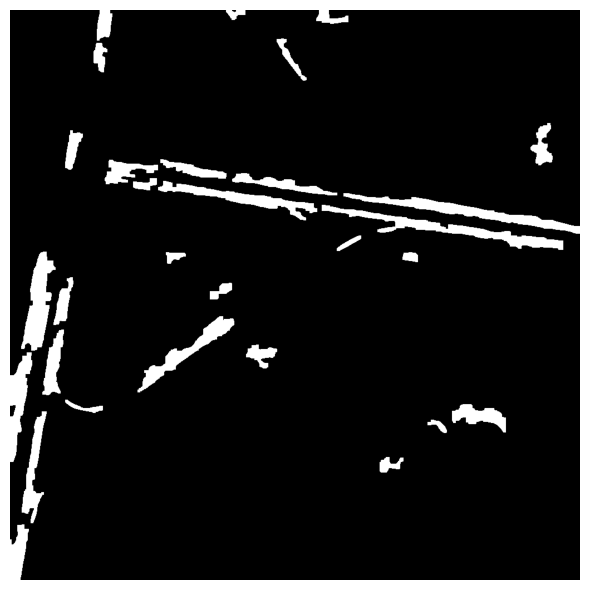

In [62]:
def filter_non_road(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    clean = np.zeros_like(mask)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 300:   # remove small noise
          continue

        # Bounding box
        x,y,w,h = cv2.boundingRect(cnt)
        aspect = max(w,h) / (min(w,h) + 1e-5)

        # Solidity (how filled the shape is)
        hull = cv2.convexHull(cnt)
        solidity = area / (cv2.contourArea(hull) + 1e-5)

        # ROAD RULE:
        # long + not too solid
        if aspect > 1.2 and solidity < 0.95:
            cv2.drawContours(clean, [cnt], -1, 255, -1) 

    return clean

Refined_mask = filter_non_road(refined_mask)
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(Refined_mask, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout(); plt.show()
 


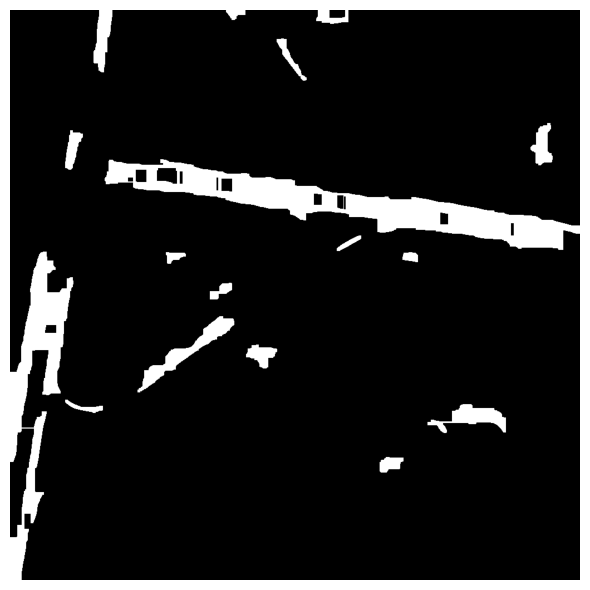

In [63]:
def connect_roads(mask):

    #kernel = np.ones((3,3), np.uint8)
    #mask = cv2.dilate(mask, kernel, iterations=1)

    # horizontal connection
    k_h = cv2.getStructuringElement(cv2.MORPH_RECT, (21,1))
    m_h = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_h)

    # vertical connection
    k_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1,21))
    m_v = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_v)

    combined = cv2.bitwise_or(mask, cv2.bitwise_or(m_h, m_v))
    return combined

# connect stage
Refined_mask_fill  = cv2.dilate(Refined_mask, np.ones((3,3), np.uint8), iterations=1)
Connected = connect_roads(Refined_mask_fill)
Connected_mask = cv2.erode(Connected, np.ones((3,3), np.uint8), iterations=1)
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(Connected_mask, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout(); plt.show()
 


Computing skeleton centerline...


C:\Users\DP_PANDA\AppData\Local\Temp\ipykernel_1944\3028764494.py:47: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary   = remove_small_objects(binary, min_size=min_sz)


  Skeleton pixels: 4,123


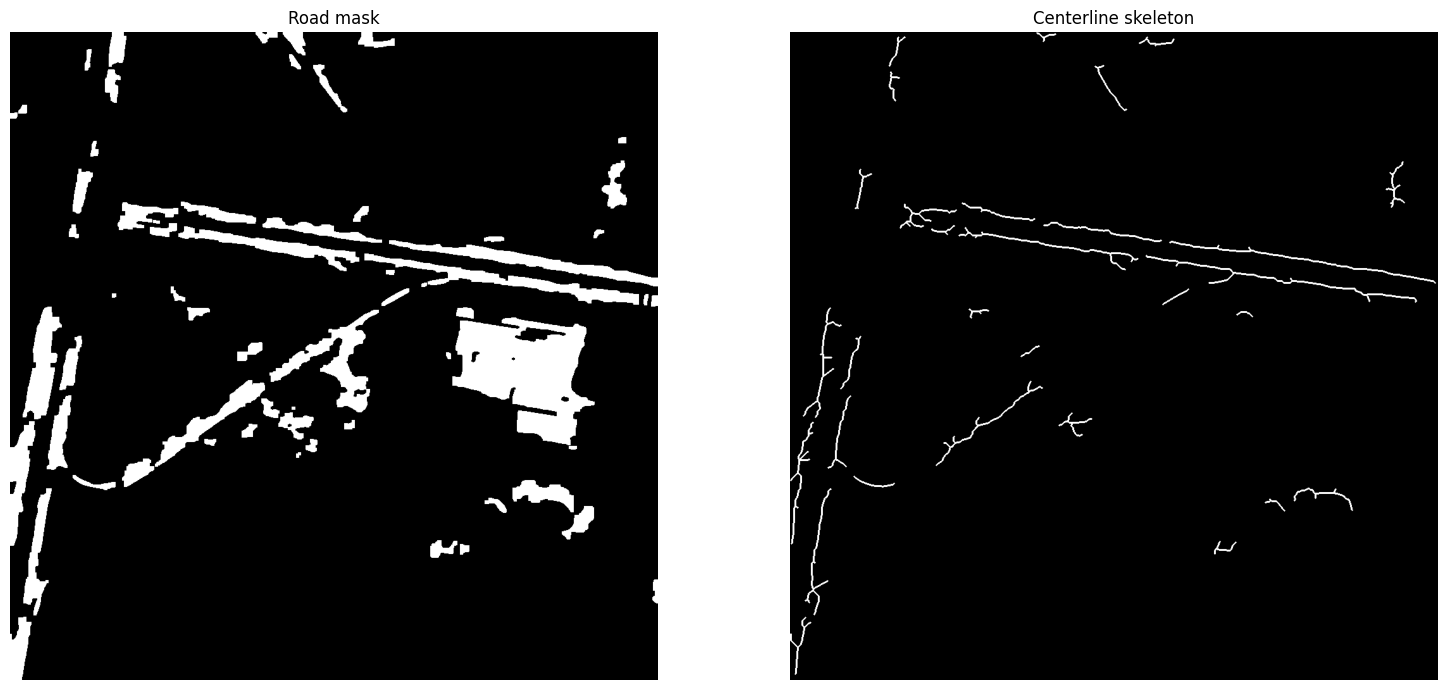

In [64]:
#Centerline refinement
def prune_spurs(skel, min_len=SPUR_MIN_LEN):
    """
    Prune short dangling branches from skeleton.
    Iterates: find endpoints (1 neighbour) → walk branch → remove if short.
    """
    s = skel.copy().astype(np.uint8)
    h2, w2 = s.shape
 
    for _ in range(8):
        changed = False
        ys, xs  = np.where(s > 0)
        for y, x in zip(ys.tolist(), xs.tolist()):
            # Count 8-connected skeleton neighbours
            patch = s[max(0,y-1):y+2, max(0,x-1):x+2]
            n     = int(patch.sum()//255) - 1   # exclude centre
            if n != 1:
                continue   # not an endpoint
            # Walk branch from endpoint
            branch = [(y, x)]
            prev   = None
            cy, cx = y, x
            while True:
                nbs = []
                for dy in [-1,0,1]:
                    for dx in [-1,0,1]:
                        if dy==0 and dx==0: continue
                        ny, nx = cy+dy, cx+dx
                        if (0<=ny<h2 and 0<=nx<w2 and
                            s[ny,nx]>0 and (ny,nx)!=prev):
                            nbs.append((ny,nx))
                if len(nbs) != 1:
                    break
                prev = (cy,cx); cy,cx = nbs[0]
                branch.append((cy,cx))
            if len(branch) < min_len:
                for (by,bx) in branch:
                    s[by,bx] = 0
                changed = True
        if not changed:
            break
    return s
 
def refine_centerline(mask):
    binary   = (mask > 0)
    min_sz   = max(100, int(MIN_ROAD_AREA_FRAC * H * W // 4))
    binary   = remove_small_objects(binary, min_size=min_sz)
    skel     = skeletonize(binary).astype(np.uint8)
    skel     = prune_spurs(skel, SPUR_MIN_LEN)
    k        = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    thick    = cv2.dilate(skel, k, iterations=1)
    return skel, thick
 
print("Computing skeleton centerline...")
skeleton, thick_skel = refine_centerline(Refined_mask)
print(f"  Skeleton pixels: {skeleton.sum():,}")
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(refined_mask, cmap='gray'); axes[0].set_title("Road mask"); axes[0].axis("off")
axes[1].imshow(thick_skel * 255, cmap='gray'); axes[1].set_title("Centerline skeleton"); axes[1].axis("off")
plt.tight_layout(); plt.show()
 

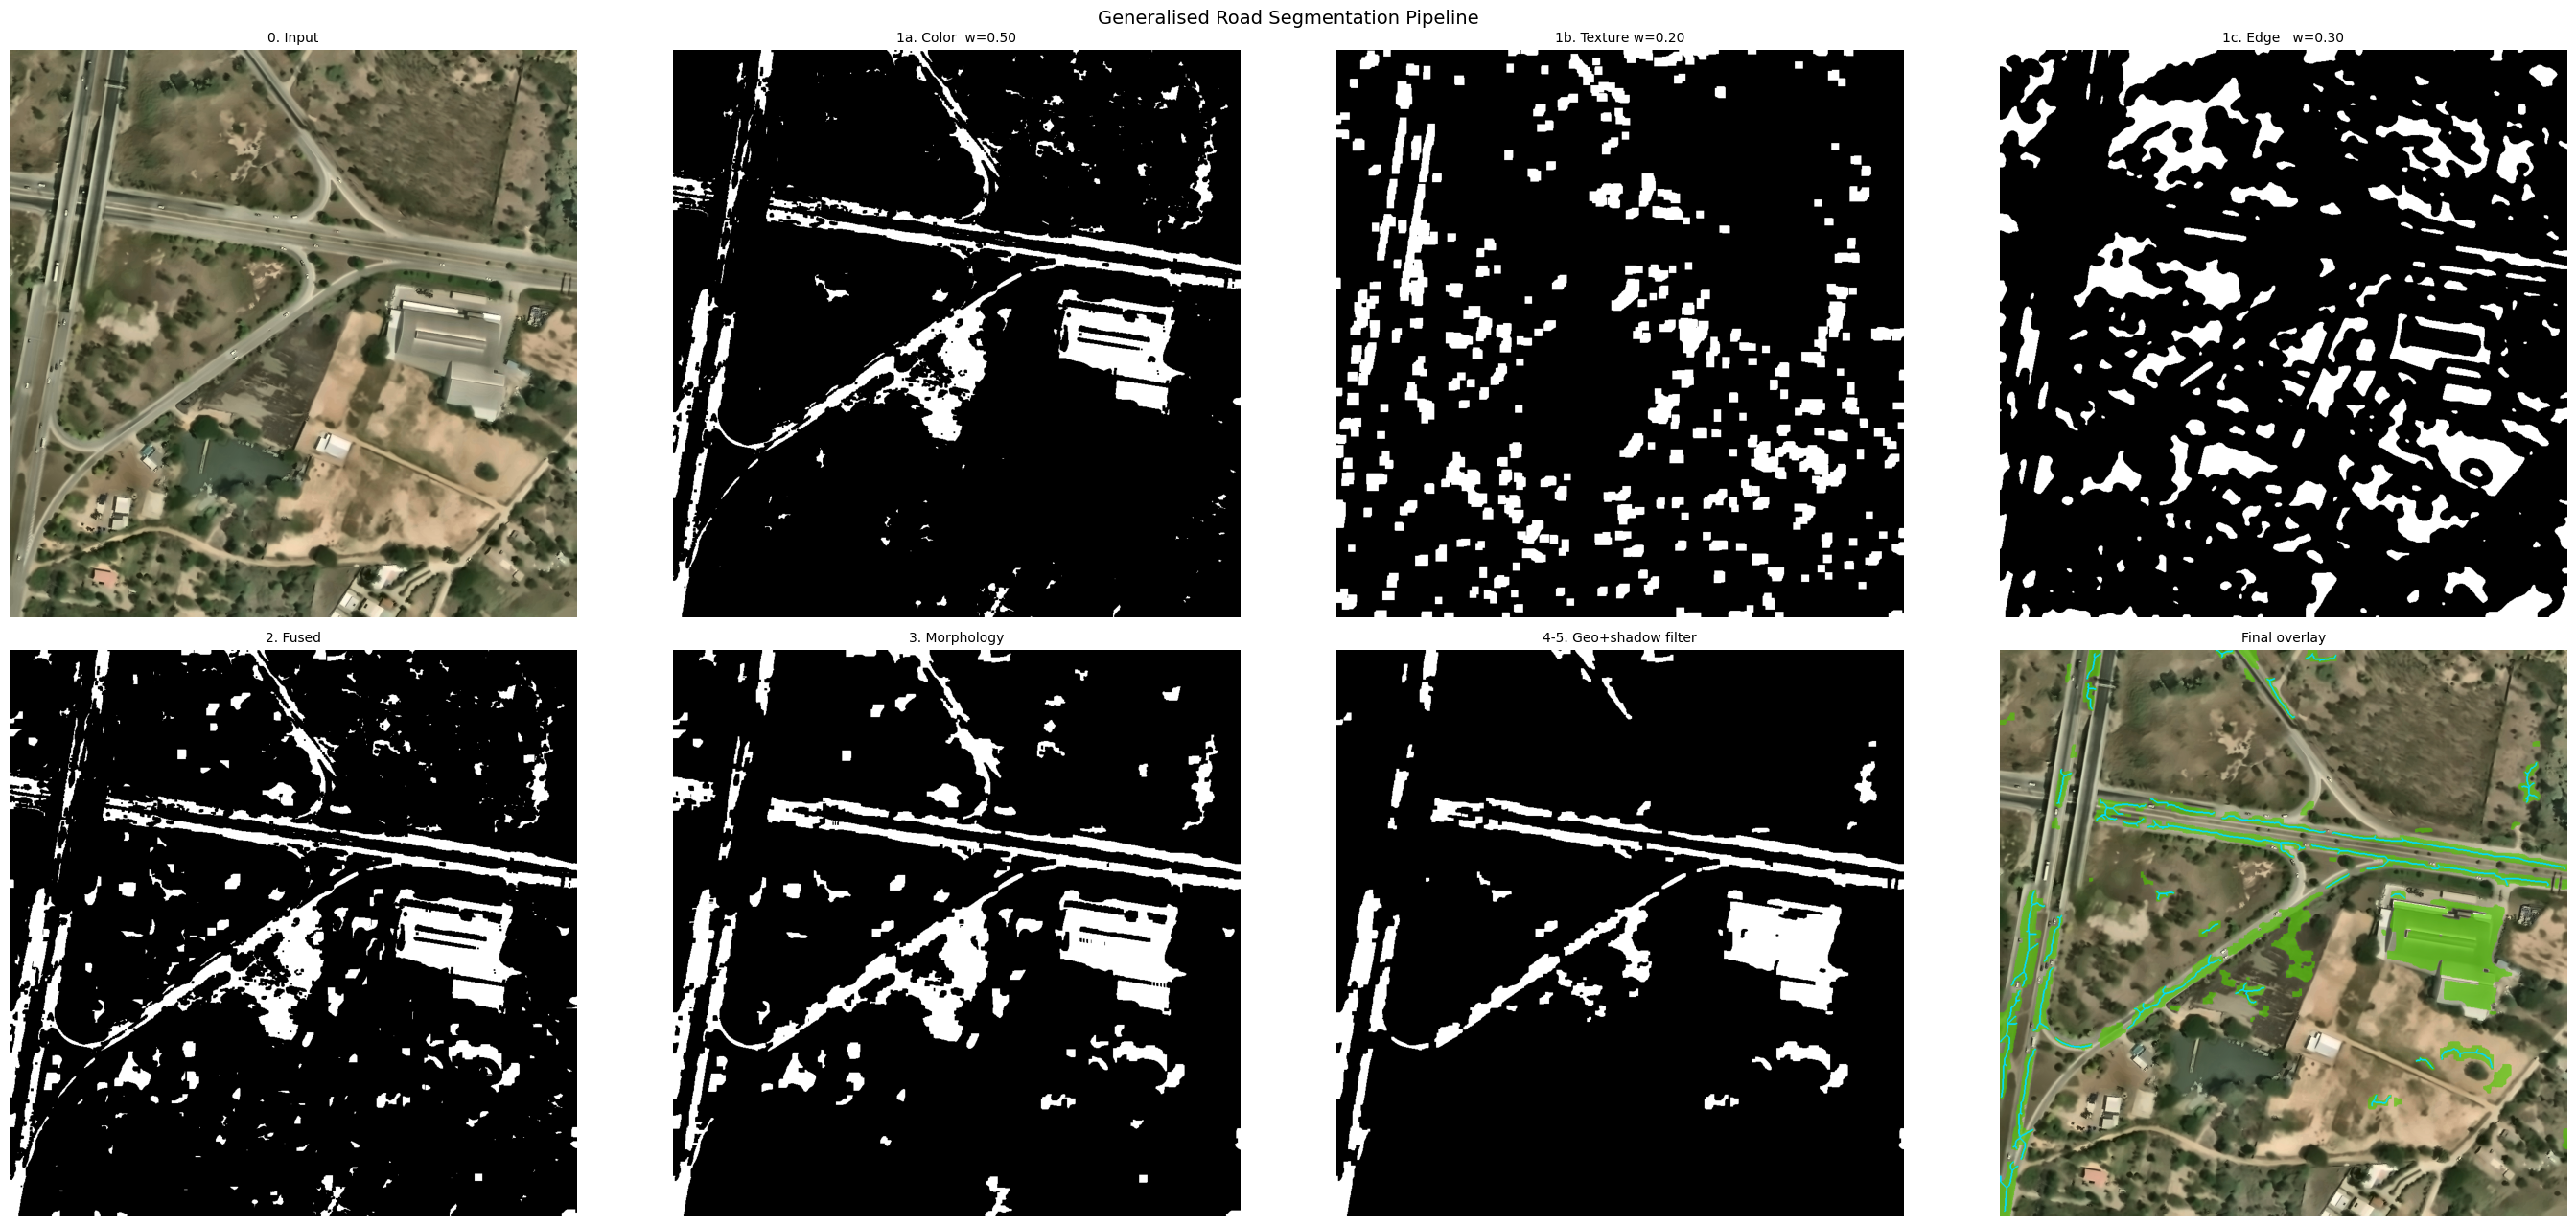

In [65]:
#Final overlay of map and save it. 
def make_overlay(base, road_mask, skeleton,
                 road_color=(0, 200, 80), skel_color=(255, 220, 0)):
    ov = base.copy()
    rp = road_mask > 0
    ov[rp] = (ov[rp].astype(np.float32)*0.35 +
              np.array(road_color, dtype=np.float32)*0.65).astype(np.uint8)
    ov[skeleton > 0] = skel_color
    return ov
 
overlay = make_overlay(img, refined_mask, thick_skel)
 
#cv2.imwrite(f"{OUTPUT_DIR}/road_mask.png",    refined_mask)
#cv2.imwrite(f"{OUTPUT_DIR}/road_skeleton.png", thick_skel * 255)
#cv2.imwrite(f"{OUTPUT_DIR}/road_overlay.jpg", overlay)
 
# Full pipeline comparison
fig, axes = plt.subplots(2, 4, figsize=(28, 13))
stages = [
    (img,                               "0. Input"),
    ((cue_color*255).astype(np.uint8),  f"1a. Color  w={weights[0]:.2f}"),
    ((cue_tex*255).astype(np.uint8),    f"1b. Texture w={weights[1]:.2f}"),
    ((cue_edge*255).astype(np.uint8),   f"1c. Edge   w={weights[2]:.2f}"),
    (raw_mask,                          "2. Fused"),
    (clean_mask,                        "3. Morphology"),
    (refined_mask,                      "4-5. Geo+shadow filter"),
    (overlay,                           "Final overlay"),
]
for ax, (im, title) in zip(axes.flat, stages):
    if im.ndim == 3:
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=10); ax.axis("off")
 
plt.suptitle("Generalised Road Segmentation Pipeline", fontsize=14)
plt.tight_layout()
#plt.savefig(f"{OUTPUT_DIR}/pipeline_comparison.jpg", dpi=150, bbox_inches='tight')
plt.show()
#print("✓ All outputs saved to output/")


── Evaluation ──────────────────
  Precision : 72.2%
  Recall    : 29.8%
  F1        : 42.2%
  IoU       : 26.8%


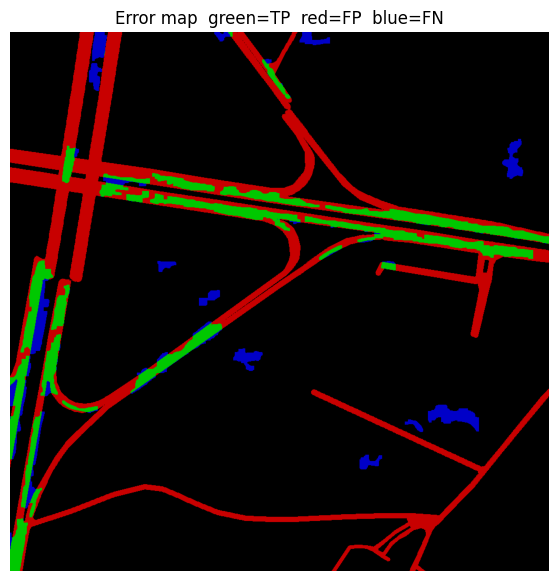

In [66]:
# Evaluation (optional — if GT mask available)
def evaluate(pred, gt_path):
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    if gt is None:
        print("GT not found — skipping."); return None
    if gt.shape != pred.shape:
        gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]),
                        interpolation=cv2.INTER_NEAREST)
    p  = (pred > 0)
    g  = (gt   > 127)
    TP = (p &  g).sum();  FP = (p & ~g).sum()
    FN = (~p & g).sum();  TN = (~p & ~g).sum()
    precision = TP/(TP+FP+1e-6);  recall = TP/(TP+FN+1e-6)
    f1  = 2*precision*recall/(precision+recall+1e-6)
    iou = TP/(TP+FP+FN+1e-6)
    print(f"\n── Evaluation ──────────────────")
    print(f"  Precision : {precision*100:.1f}%")
    print(f"  Recall    : {recall*100:.1f}%")
    print(f"  F1        : {f1*100:.1f}%")
    print(f"  IoU       : {iou*100:.1f}%")
    err = np.zeros((*gt.shape, 3), dtype=np.uint8)
    err[ p &  g]  = [0, 200, 0]
    err[ p & ~g]  = [200, 0, 0]
    err[~p &  g]  = [0, 0, 200]
    #cv2.imwrite(f"{OUTPUT_DIR}/error_map.jpg", err)
    plt.figure(figsize=(10,7))
    plt.imshow(cv2.cvtColor(err, cv2.COLOR_BGR2RGB))
    plt.title("Error map  green=TP  red=FP  blue=FN")
    plt.axis("off"); plt.show()
    return {"iou": iou, "f1": f1, "precision": precision, "recall": recall}
 
if GT_PATH:
    metrics = evaluate(Refined_mask, GT_PATH)
 

In [67]:
print("""
TUNING GUIDE FOR GENERALISATION
================================
 
Roads missing (under-detection):
  FUSION_THRESH  0.38 → 0.28   (accept weaker agreement between cues)
  MIN_ASPECT     2.2  → 1.8    (accept less-elongated shapes)
 
Too many false positives:
  FUSION_THRESH  0.38 → 0.48   (require stronger cue agreement)
  MAX_SOLIDITY   0.87 → 0.80   (remove more compact blobs)
  SHADOW_L_MAX   60   → 75     (remove more dark regions)
 
Roads broken/disconnected:
  In morph_cleanup: increase base or iterations
 
Works on satellite but fails on Google Maps:
  detect_image_type() auto-handles this; if detection is wrong,
  force img_type = 'map_styled' in preprocess() call
 
Works on one image but fails on another:
  The adaptive Otsu thresholds should self-adjust.
  Check cue confidence scores printed in Cell 7 —
  if all three confidences are low (<0.4), the image may be
  unusual (heavy cloud cover, night imagery, etc.)
""")


TUNING GUIDE FOR GENERALISATION

Roads missing (under-detection):
  FUSION_THRESH  0.38 → 0.28   (accept weaker agreement between cues)
  MIN_ASPECT     2.2  → 1.8    (accept less-elongated shapes)

Too many false positives:
  FUSION_THRESH  0.38 → 0.48   (require stronger cue agreement)
  MAX_SOLIDITY   0.87 → 0.80   (remove more compact blobs)
  SHADOW_L_MAX   60   → 75     (remove more dark regions)

Roads broken/disconnected:
  In morph_cleanup: increase base or iterations

Works on satellite but fails on Google Maps:
  detect_image_type() auto-handles this; if detection is wrong,
  force img_type = 'map_styled' in preprocess() call

Works on one image but fails on another:
  The adaptive Otsu thresholds should self-adjust.
  Check cue confidence scores printed in Cell 7 —
  if all three confidences are low (<0.4), the image may be
  unusual (heavy cloud cover, night imagery, etc.)



In [71]:
"""
More possible algorithms:
  - Frangi vesselness filter    : detects tube-like structures via Hessian
  - Parallel edge pair detector : fills between Hough line pairs
  - LBP texture uniformity      : colour-independent smoothness cue
  - Topology enforcement        : reconnects broken road segments
"""


'\nMore possible algorithms:\n  - Frangi vesselness filter    : detects tube-like structures via Hessian\n  - Parallel edge pair detector : fills between Hough line pairs\n  - LBP texture uniformity      : colour-independent smoothness cue\n  - Topology enforcement        : reconnects broken road segments\n'